<a href="https://colab.research.google.com/github/nadiayerko/Data/blob/main/ProyectoParteIII%2BYerkovich.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introducción**
En este proyecto final se busca aplicar técnicas de selección de variables, entrenamiento de un modelo de regresión y validación del mismo utilizando un conjunto de datos agronómicos relacionados con la producción de soja en distintas provincias de Argentina. El objetivo es construir un modelo que permita predecir la producción de soja en toneladas a partir de variables climáticas y de calidad del cultivo.


# Objetivos
-Reducir la dimensionalidad del dataset mediante técnicas de selección de variables.

-Entrenar un modelo de regresión para predecir la producción de soja (produccion_tn).

-Validar el rendimiento del modelo utilizando métricas apropiadas.

-Obtener conclusiones sobre las variables más relevantes y la calidad predictiva del modelo.

PREGUNTAS E HIPÓTESIS
Preguntas:
1. ¿Existe una relación entre la superficie sembrada, la superficie cosechada y la producción en millones de toneladas?
2. ¿Se puede estimar la producción de soja para la próxima campaña?


Hipótesis:
- H1: Existe una correlación positiva entre superficie sembrada y producción total.
- H2: No Existe una correlación positiva entre superficie sembrada y producción total.

In [18]:
### Proyecto Data science Parte III Yerkovich ###

# Paso 1: Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Cargar el archivo directamente desde un repositorio de GitHub
url = "https://raw.githubusercontent.com/nadiayerko/Data/main/Produccion.csv"

import pandas as pd

df = pd.read_csv(url, encoding='latin-1')
print(df.head())

# Limpiar los nombres de las columnas
# (eliminar espacios, pasar a minúsculas y reemplazar espacios por guiones bajos)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Mostrar las primeras filas para verificar
df.head()
url = "https://raw.githubusercontent.com/nadiayerko/Data/main/Produccion.csv"

df = pd.read_csv(url, encoding='latin-1')
print(df.head())

# Limpiar los nombres de las columnas
# (eliminar espacios, pasar a minúsculas y reemplazar espacios por guiones bajos)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Mostrar las primeras filas para verificar
df.head()

  cultivo_nombre  anio   campania provincia_nombre  provincia_id  \
0           soja  1941  1941/1942         Santa Fe            82   
1           soja  1941  1941/1942         Santa Fe            82   
2           soja  1941  1941/1942         Santa Fe            82   
3           soja  1941  1941/1942         Santa Fe            82   
4           soja  1941  1941/1942         Santa Fe            82   

  departamento_nombre  departamento_id  superficie_sembrada_ha  \
0            Belgrano          82007.0                      90   
1             Caseros          82014.0                      45   
2       ConstituciÃ³n          82028.0                      50   
3      General LÃ³pez          82042.0                      80   
4             Iriondo          82056.0                      70   

   superficie_cosechada_ha  produccion_tm  rendimiento_kgxha  
0                       90            153               1700  
1                       35             18                514  
2    

,cultivo_nombre,anio,campania,provincia_nombre,provincia_id,departamento_nombre,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha
0,soja,1941,1941/1942,Santa Fe,82,Belgrano,82007.0,90,90,153,1700
1,soja,1941,1941/1942,Santa Fe,82,Caseros,82014.0,45,35,18,514
2,soja,1941,1941/1942,Santa Fe,82,ConstituciÃ³n,82028.0,50,50,100,2000
3,soja,1941,1941/1942,Santa Fe,82,General LÃ³pez,82042.0,80,65,32,492
4,soja,1941,1941/1942,Santa Fe,82,Iriondo,82056.0,70,70,112,1600


In [20]:
# GENERACION DE NUEVA VARIABLES

# Semilla para reproducibilidad
np.random.seed(42)

# Agregar columnas inventadas
n = len(df)

# Humedad del suelo (%): entre 10% y 40%
df['humedad_suelo'] = np.random.uniform(10, 40, n).round(2)

# Temperatura de cosecha (°C): entre 15°C y 35°C
df['temperatura_cosecha'] = np.random.uniform(15, 35, n).round(1)

# Proteínas (% en base seca): entre 32% y 44%
df['proteinas'] = np.random.uniform(32, 44, n).round(2)

# Aceite (% en base seca): entre 18% y 24%
df['aceite'] = np.random.uniform(18, 24, n).round(2)

# Mostrar las primeras filas para verificar
df.head()


,cultivo_nombre,anio,campania,provincia_nombre,provincia_id,departamento_nombre,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,humedad_suelo,temperatura_cosecha,proteinas,aceite
0,soja,1941,1941/1942,Santa Fe,82,Belgrano,82007.0,90,90,153,1700,21.24,27.5,37.47,22.06
1,soja,1941,1941/1942,Santa Fe,82,Caseros,82014.0,45,35,18,514,38.52,33.2,38.18,21.27
2,soja,1941,1941/1942,Santa Fe,82,ConstituciÃ³n,82028.0,50,50,100,2000,31.96,20.5,38.24,23.58
3,soja,1941,1941/1942,Santa Fe,82,General LÃ³pez,82042.0,80,65,32,492,27.96,25.1,43.40,21.71
4,soja,1941,1941/1942,Santa Fe,82,Iriondo,82056.0,70,70,112,1600,14.68,34.2,39.79,19.28


In [21]:
#Finalmente, guardamos el nuevo DataFrame en un archivo CSV para usarlo luego:

# Guardar el nuevo DataFrame en un archivo CSV
df.to_csv("Produccion.csv", index=False)

df.head()

,cultivo_nombre,anio,campania,provincia_nombre,provincia_id,departamento_nombre,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,humedad_suelo,temperatura_cosecha,proteinas,aceite
0,soja,1941,1941/1942,Santa Fe,82,Belgrano,82007.0,90,90,153,1700,21.24,27.5,37.47,22.06
1,soja,1941,1941/1942,Santa Fe,82,Caseros,82014.0,45,35,18,514,38.52,33.2,38.18,21.27
2,soja,1941,1941/1942,Santa Fe,82,ConstituciÃ³n,82028.0,50,50,100,2000,31.96,20.5,38.24,23.58
3,soja,1941,1941/1942,Santa Fe,82,General LÃ³pez,82042.0,80,65,32,492,27.96,25.1,43.40,21.71
4,soja,1941,1941/1942,Santa Fe,82,Iriondo,82056.0,70,70,112,1600,14.68,34.2,39.79,19.28


In [22]:
# DESCARGA DE DATA FRAME PARA CHEQUEO

df.to_csv("Produccion_modificado.csv", index=False) # Usamos un nuevo nombre para distinguirlo

print("DataFrame guardado como 'Produccion_modificado.csv' en el entorno de Colab.")

try:
  files.download("Produccion_modificado.csv")
  print("Archivo 'Produccion_modificado.csv' descargado.")
except Exception as e:
  print(f"Error al descargar el archivo: {e}")
  print("Asegúrate de que el archivo se haya guardado correctamente y revisa los permisos.")

DataFrame guardado como 'Produccion_modificado.csv' en el entorno de Colab.
Error al descargar el archivo: name 'files' is not defined
Asegúrate de que el archivo se haya guardado correctamente y revisa los permisos.


**Metodología**

Cargar y preparar los datos.

Aplicar feature selection.

Separar los datos en entrenamiento y test.

Entrenar un modelo de regresión.

Validar con métricas de evaluación.

Extraer conclusiones sobre el modelo y las variables seleccionadas.

In [23]:
df = pd.read_csv("Produccion_modificado.csv")
df.head()


,cultivo_nombre,anio,campania,provincia_nombre,provincia_id,departamento_nombre,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,humedad_suelo,temperatura_cosecha,proteinas,aceite
0,soja,1941,1941/1942,Santa Fe,82,Belgrano,82007.0,90,90,153,1700,21.24,27.5,37.47,22.06
1,soja,1941,1941/1942,Santa Fe,82,Caseros,82014.0,45,35,18,514,38.52,33.2,38.18,21.27
2,soja,1941,1941/1942,Santa Fe,82,ConstituciÃ³n,82028.0,50,50,100,2000,31.96,20.5,38.24,23.58
3,soja,1941,1941/1942,Santa Fe,82,General LÃ³pez,82042.0,80,65,32,492,27.96,25.1,43.40,21.71
4,soja,1941,1941/1942,Santa Fe,82,Iriondo,82056.0,70,70,112,1600,14.68,34.2,39.79,19.28


In [24]:
# Variables predictoras y variable target
X = df[['humedad_suelo', 'proteinas', 'temperatura_cosecha', 'aceite']]
y = df['produccion_tm']


In [25]:
import pandas as pd

# Verificar columnas disponibles
df.columns


Index(['cultivo_nombre', 'anio', 'campania', 'provincia_nombre',
       'provincia_id', 'departamento_nombre', 'departamento_id',
       'superficie_sembrada_ha', 'superficie_cosechada_ha', 'produccion_tm',
       'rendimiento_kgxha', 'humedad_suelo', 'temperatura_cosecha',
       'proteinas', 'aceite'],
      dtype='object')

In [26]:
# Mostrar información del DataFrame
print("Información del DataFrame en la misma sesión:")
df.info()

# Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())

Información del DataFrame en la misma sesión:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12303 entries, 0 to 12302
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cultivo_nombre           12303 non-null  object 
 1   anio                     12303 non-null  int64  
 2   campania                 12303 non-null  object 
 3   provincia_nombre         12303 non-null  object 
 4   provincia_id             12303 non-null  int64  
 5   departamento_nombre      12303 non-null  object 
 6   departamento_id          12254 non-null  float64
 7   superficie_sembrada_ha   12303 non-null  int64  
 8   superficie_cosechada_ha  12303 non-null  int64  
 9   produccion_tm            12303 non-null  int64  
 10  rendimiento_kgxha        12303 non-null  int64  
 11  humedad_suelo            12303 non-null  float64
 12  temperatura_cosecha      12303 non-null  float64
 13  proteinas                12303

,anio,provincia_id,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,humedad_suelo,temperatura_cosecha,proteinas,aceite
count,12303.000000,12303.000000,12254.000000,12303.000000,12303.000000,1.230300e+04,12303.000000,12303.000000,12303.000000,12303.000000,12303.000000
mean,1997.494595,33.767211,33909.532316,41110.423149,39900.288548,1.033344e+05,2007.240836,24.887078,25.131285,37.938150,20.988916
std,17.483400,30.230639,30120.622579,80938.740280,79365.004380,2.315423e+05,823.110090,8.646321,5.777031,3.446829,1.738984
min,1941.000000,6.000000,6007.000000,1.000000,0.000000,0.000000e+00,0.000000,10.000000,15.000000,32.000000,18.000000
25%,1984.000000,6.000000,6651.000000,680.000000,600.000000,1.000000e+03,1450.000000,17.420000,20.100000,34.940000,19.480000
50%,2000.000000,22.000000,22049.000000,7000.000000,6400.000000,1.222100e+04,2000.000000,24.820000,25.200000,37.950000,20.970000
75%,2012.000000,54.000000,54112.000000,45455.000000,43090.000000,9.666000e+04,2520.000000,32.360000,30.100000,40.870000,22.520000
max,2023.000000,90.000000,90119.000000,894613.000000,883613.000000,2.637503e+06,20000.000000,39.990000,35.000000,44.000000,24.000000


# Esta sección fue realizada para saber si podemos usar la variable producción de soja para determinar proteínas. Pero no hubo correlación.

In [27]:
##Correlación entre variables = 0
corr = df[['proteinas', 'produccion_tm']].corr()
print(corr)


               proteinas  produccion_tm
proteinas       1.000000       0.000806
produccion_tm   0.000806       1.000000


In [28]:
#Para determinar normalidad numéricamente, un test estadístico:

#Shapiro-Wilk (para < 5000 muestras):

from scipy.stats import shapiro

stat, p = shapiro(df['proteinas'].dropna())
print(f'Estadístico: {stat:.3f}, p-valor: {p:.3f}')

if p > 0.05:
    print("Distribución normal")
else:
    print("No es distribución normal")

#### No es NORMAL

Estadístico: 0.956, p-valor: 0.000
No es distribución normal


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12303.
  res = hypotest_fun_out(*samples, **kwds)


In [29]:
## Kolmogorov-Smirnov o Anderson-Darling:

from scipy.stats import normaltest

stat, p = normaltest(df['proteinas'].dropna())
print(f'Estadístico: {stat:.3f}, p-valor: {p:.3f}')

if p > 0.05:
    print("Distribución normal")
else:
    print("No es distribución normal")


Estadístico: 10330.834, p-valor: 0.000
No es distribución normal


In [30]:
## Chequeamos datos
df.head()

,cultivo_nombre,anio,campania,provincia_nombre,provincia_id,departamento_nombre,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,humedad_suelo,temperatura_cosecha,proteinas,aceite
0,soja,1941,1941/1942,Santa Fe,82,Belgrano,82007.0,90,90,153,1700,21.24,27.5,37.47,22.06
1,soja,1941,1941/1942,Santa Fe,82,Caseros,82014.0,45,35,18,514,38.52,33.2,38.18,21.27
2,soja,1941,1941/1942,Santa Fe,82,ConstituciÃ³n,82028.0,50,50,100,2000,31.96,20.5,38.24,23.58
3,soja,1941,1941/1942,Santa Fe,82,General LÃ³pez,82042.0,80,65,32,492,27.96,25.1,43.40,21.71
4,soja,1941,1941/1942,Santa Fe,82,Iriondo,82056.0,70,70,112,1600,14.68,34.2,39.79,19.28


In [31]:
## Chequeamos nombres de las variables
print(df.columns)

Index(['cultivo_nombre', 'anio', 'campania', 'provincia_nombre',
       'provincia_id', 'departamento_nombre', 'departamento_id',
       'superficie_sembrada_ha', 'superficie_cosechada_ha', 'produccion_tm',
       'rendimiento_kgxha', 'humedad_suelo', 'temperatura_cosecha',
       'proteinas', 'aceite'],
      dtype='object')


In [32]:
## Selección de variables y codificación de provincia_nombre

# Seleccionamos variables de interés
variables_modelo = ['aceite', 'produccion_tm', 'temperatura_cosecha',
                    'humedad_suelo', 'rendimiento_kgxha', 'provincia_nombre', 'proteinas']

df_modelo = df[variables_modelo].copy()

# Codificamos la columna provincia_nombre
df_modelo = pd.get_dummies(df_modelo, columns=['provincia_nombre'], drop_first=True)

# Separación de X (features) e y (target)
X = df_modelo.drop('proteinas', axis=1)
y = df_modelo['proteinas']


In [33]:
#Se desea saber si las variables a correlacionar tiene efecto sobre la producción para ajustar el modelo a entrenar

df.corr(numeric_only=True)['produccion_tm'].sort_values(ascending=False)


,produccion_tm
produccion_tm,1.000000
superficie_cosechada_ha,0.963616
superficie_sembrada_ha,0.959071
rendimiento_kgxha,0.430611
anio,0.281536
provincia_id,0.033351
departamento_id,0.031833
temperatura_cosecha,0.007895
proteinas,0.000806
humedad_suelo,0.000114


In [34]:
#Se desea saber si las variables a correlacionar tiene efecto sobre el rendimiento para ajustar el modelo a entrenar


df.corr(numeric_only=True)['rendimiento_kgxha'].sort_values(ascending=False)


,rendimiento_kgxha
rendimiento_kgxha,1.000000
anio,0.556299
produccion_tm,0.430611
superficie_cosechada_ha,0.355880
superficie_sembrada_ha,0.347856
temperatura_cosecha,0.013217
humedad_suelo,0.003038
proteinas,-0.003335
aceite,-0.005178
departamento_id,-0.009931


# Se plantea la necesidad de hacer los entrenamientos del modelo para menos cantidad de campañas probando entrenar el modelo para predecir la producción con Random forest y regresion lineal.

In [35]:
#Selecciona menos cantidad de años y se seleccionan variables superficie cosechada y sembrada, rendimiento y producción.

import pandas as pd
from sklearn.model_selection import train_test_split


# Filtrar los últimos 5 años disponibles en la columna 'anio'
ultimos_5_anios = sorted(df['anio'].unique())[-5:]
df_filtrado = df[df['anio'].isin(ultimos_5_anios)].copy()

print("Años incluidos:", df_filtrado['anio'].unique())

# Variables seleccionadas
variables = ['superficie_cosechada_ha', 'superficie_sembrada_ha', 'rendimiento_kgxha', 'produccion_tm']
df_modelo = df_filtrado[variables].copy()

# Separación de variables predictoras (X) y variable objetivo (y)
X = df_modelo.drop('produccion_tm', axis=1)
y = df_modelo['produccion_tm']

# División en conjuntos de entrenamiento y testeo (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificamos las dimensiones
print("Entrenamiento:", X_train.shape, y_train.shape)
print("Testeo:", X_test.shape, y_test.shape)



Años incluidos: [2019 2020 2021 2022 2023]
Entrenamiento: (1111, 3) (1111,)
Testeo: (278, 3) (278,)


# Random forest y regresión lineal
Evaluación de los modelos y visualización de las métricas

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ---- MODELO 1: Regresión Lineal ----
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# ---- MODELO 2: Random Forest Regressor ----
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ---- Función para imprimir métricas ----
def evaluar_modelo(y_test, y_pred, nombre_modelo):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{nombre_modelo} - Resultados:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.4f}")

# ---- Evaluar ambos modelos ----
evaluar_modelo(y_test, y_pred_lr, "Regresión Lineal")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")



Regresión Lineal - Resultados:
MSE: 5247396723.32
RMSE: 72438.92
MAE: 37442.67
R² Score: 0.9322

Random Forest - Resultados:
MSE: 1847598155.44
RMSE: 42983.70
MAE: 10188.87
R² Score: 0.9761


# Los modelos funcionan muy bien! Tienen buenos resultados

In [37]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k='all')  # Podés poner k=3, por ejemplo
X_new = selector.fit_transform(X, y)

# Para ver qué variables fueron más importantes:
import pandas as pd
scores = selector.scores_
columnas = X.columns
ranking = pd.DataFrame({'Variable': columnas, 'Score': scores}).sort_values(by='Score', ascending=False)
print(ranking)


                  Variable         Score
0  superficie_cosechada_ha  14005.244659
1   superficie_sembrada_ha  11763.790275
2        rendimiento_kgxha    206.825249


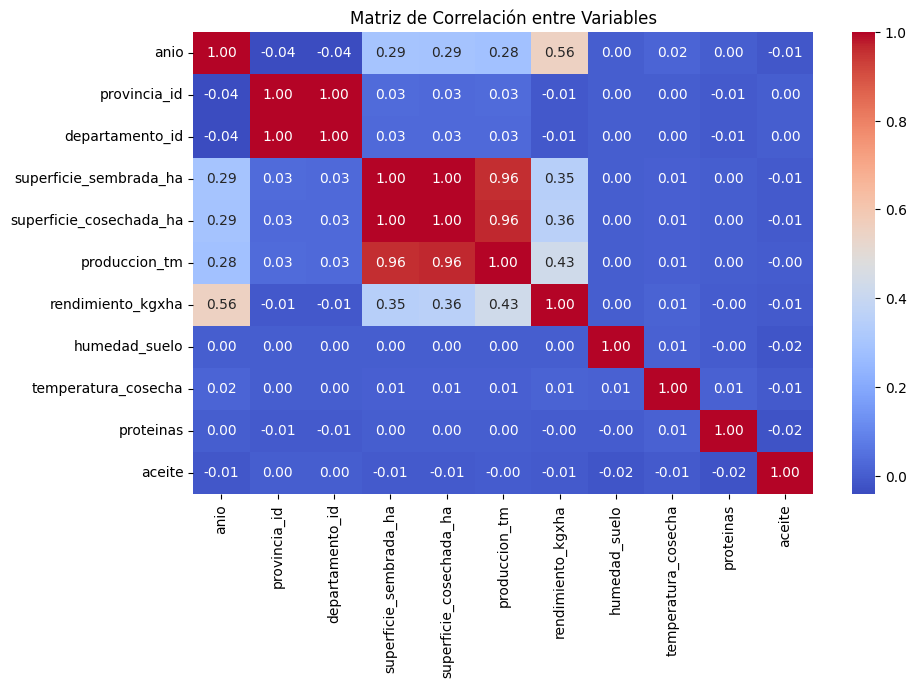

In [38]:
#Las métricas en matplotlib para visualizar las variables que influyen en el modelo
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación entre Variables')
plt.show()


# Random Forest
La variable que aporta más valor es la superficie cosechada para el modelo random forest

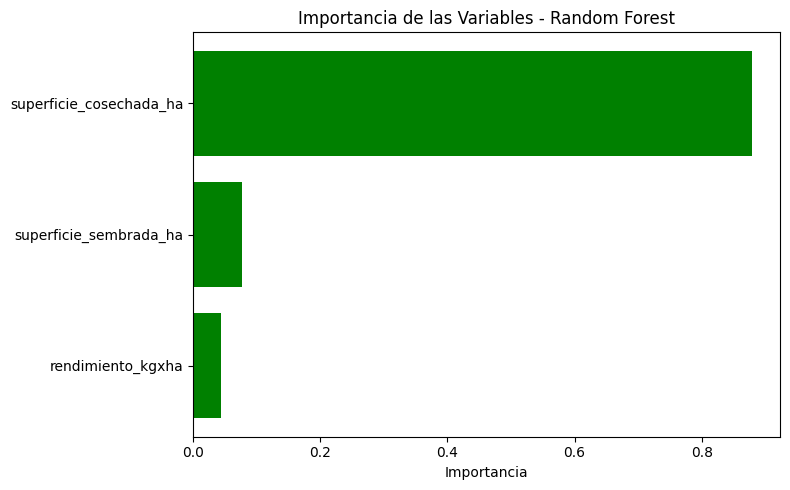

In [39]:

import pandas as pd
import matplotlib.pyplot as plt

importancias = rf.feature_importances_
features = X.columns

df_importancias = pd.DataFrame({'Variable': features, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='green')
plt.xlabel('Importancia')
plt.title('Importancia de las Variables - Random Forest')
plt.tight_layout()
plt.show()


## Variables más importantes vs producción

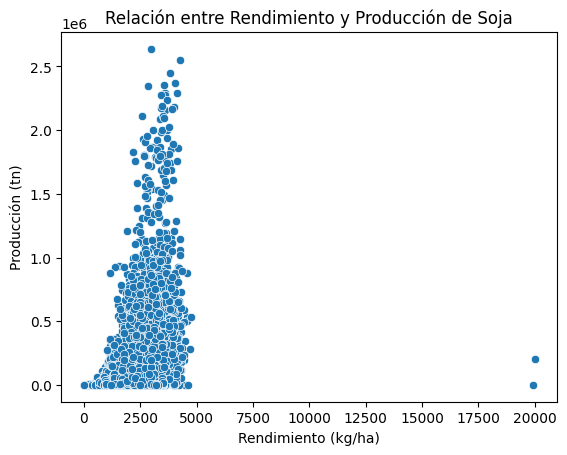

In [40]:
# Variables más importantes vs producción

###Rendimiento###
import seaborn as sns

# Cambiá 'rendimiento_kgxha' por las que elijas
sns.scatterplot(data=df, x='rendimiento_kgxha', y='produccion_tm')
plt.title('Relación entre Rendimiento y Producción de Soja')
plt.xlabel('Rendimiento (kg/ha)')
plt.ylabel('Producción (tn)')
plt.show()


# Variables más importantes vs producción

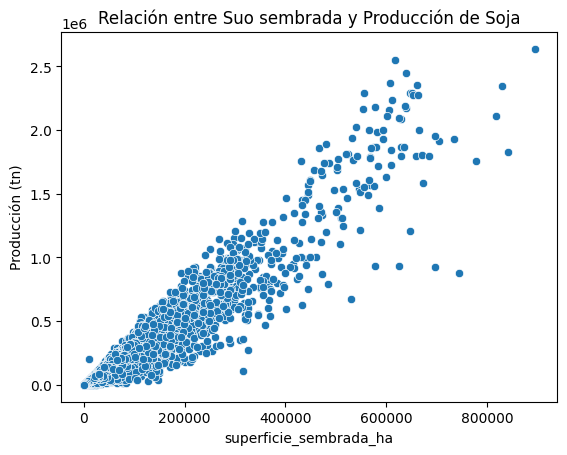

In [15]:
# Variables más importantes vs producción

###superficie sembrada###
import seaborn as sns

# Cambiá 'superficie sembrada' por las que elijas
sns.scatterplot(data=df, x='superficie_sembrada_ha', y='produccion_tm')
plt.title('Relación entre Suo sembrada y Producción de Soja')
plt.xlabel('superficie_sembrada_ha')
plt.ylabel('Producción (tn)')
plt.show()


#### para superficie cosechada va a ser el mismo gráfico. Los datos son practicamente iguales en el dataset ####

# Conclusiones
• Las variables agronómicas más importantes para la predicción de producción fueron el rendimiento, la superficie sembrada y cosechada.

• Random Forest se destacó como el modelo más preciso.

• El análisis puede usarse para estimaciones regionales futuras y para apoyar la toma de decisiones en campañas agrícolas.